In [1]:
!pip install pillow

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

**The governing equations are:**
$$\frac{\partial z}{\partial t} = U - KA^m(\frac{\partial z}{\partial x})^n$$
$$x = cA^h + A_0$$

**First we define our initial line $z(x)$**

In [3]:
L = 100000.0
nx = 5000
dx = L / (nx - 1)
x = np.linspace(0.1, L, nx)
z = np.linspace(1000, 0, nx)

**Next, we define our parameters for the Stream Power Equation using Hack's Law**

In [4]:
m, n, c, h, A_0 = 0.5, 1.0, 1.0, 0.5, 2000.0
A_m_init = (((x / c)**(1.0 / h))**m)+A_0
U_init = np.full(nx, 0.1)
K_init = np.full(nx, 0.001)

**Then we define the time and timestep parameters for the model run**

In [5]:
time_per_simulation = 5000
dt = 0.1  
num_steps = int(time_per_simulation / dt)
save_interval = 100 

**Now we perform an initial run to allow our model to reach steady state**

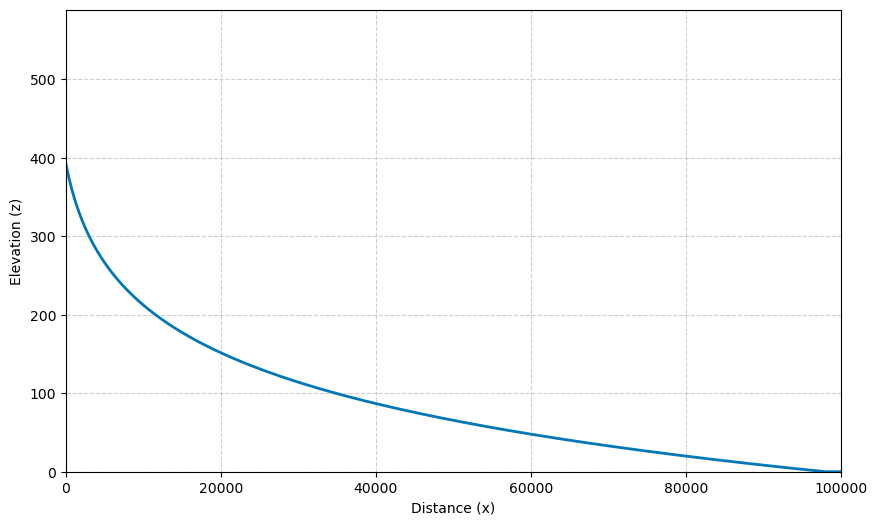

In [6]:
for step in range(num_steps):

    dzdx = np.zeros(nx)
    dzdx[:-1] = (z[:-1] - z[1:]) / dx 
    dzdx = np.maximum(dzdx, .001)
    
    E = K_init * A_m_init * (dzdx**n)    # stream power incision equation
    z += (U_init - E) * dt
    z[-1] = 0.0                          # base level boundary condition

    z = np.maximum(z, 0)

z_steady_state = z.copy()

fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_steady_state, color='#0077b6', lw=2)

ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, L)
ax.set_ylim(0, np.max(z) * 1.5) 
ax.grid(True, linestyle='--', alpha=0.6)

**Now we change our parameters**

In [8]:
m, n, c, h, A_0 = 0.5, 1.0, 1.0, 0.5, 2000.0
A_m_fin = (((x / c)**(1.0 / h))**m)+A_0
U_fin = np.full(nx, 0.1)
#U_fin [(x < 60000)] = 0.2       # clips area to change uplift then defines new uplift value
K_fin = np.full(nx, 0.001) 
K_fin [(x > 70000) & (x < 100000)] = 0.005      # clips area to change erodibility then defines new erodibility value

**And rerun the model from our initial steady state profile**

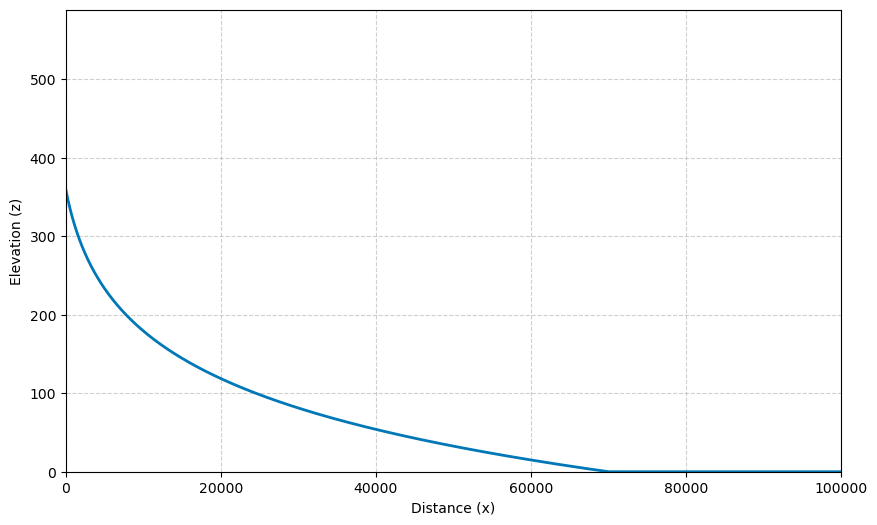

In [9]:
z_store = [z.copy()] 
z1 = z_steady_state.copy()

for step in range(num_steps):

    dzdx = np.zeros(nx)
    dzdx[:-1] = (z1[:-1] - z1[1:]) / dx 
    dzdx = np.maximum(dzdx, .001)
    
    E = K_fin * A_m_fin * (dzdx**n) 
    z1 += (U_fin - E) * dt
    z1[-1] = 0.0

    z1 = np.maximum(z1, 0)
    
    if step % save_interval == 0:
        z_store.append(z1.copy())

fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_store[-1], color='#0077b6', lw=2)

ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, L)
ax.set_ylim(0, np.max(z_store[0]) * 1.5) 
ax.grid(True, linestyle='--', alpha=0.6)

**We also save the gif animation**

In [10]:
def update(frame):
    line.set_ydata(z_store[frame])
    ax.set_title(f'Stream Profile Evolution - Time: {frame * save_interval * dt:.0f}')
    return line,

ani = FuncAnimation(fig, update, frames=len(z_store), interval=50, blit=True)

print("Saving animation... this may take a moment.")
ani.save('stream_evolution.gif', writer='pillow', fps=20)
print("Animation saved as stream_evolution.gif")

Saving animation... this may take a moment.
Animation saved as stream_evolution.gif


**And compare the before and after profiles**

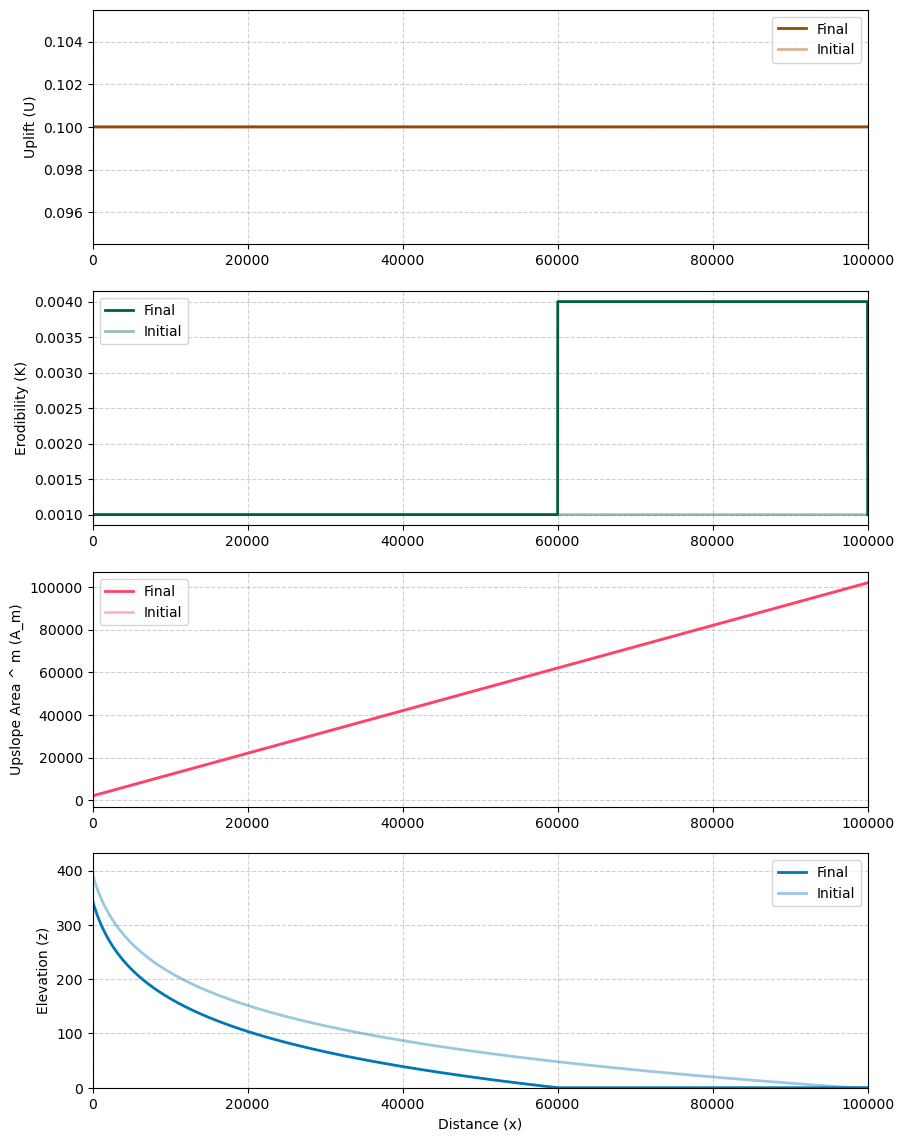

In [394]:
fig, ax = plt.subplots(4,1,figsize=(10, 14))

ax[0].plot(x, U_fin, color='#964b00', lw=2, label='Final')
ax[0].plot(x, U_init, color='#964b00', lw=2, alpha=.4, label='Initial')
ax[0].set_ylabel('Uplift (U)')
ax[0].set_xlim(0, L)
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

ax[1].plot(x, K_fin, color='#006039', lw=2, label='Final')
ax[1].plot(x, K_init, color='#006039', lw=2, alpha=.4, label='Initial')
ax[1].set_ylabel('Erodibility (K)')
ax[1].set_xlim(0, L)
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

ax[2].plot(x, A_m_fin, color='#ff4268', lw=2, label='Final')
ax[2].plot(x, A_m_init, color='#ff4268', lw=2, alpha=.4, label='Initial')
ax[2].set_ylabel('Upslope Area ^ m (A_m)')
ax[2].set_xlim(0, L)
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].legend()

ax[3].plot(x, z_store[-1], color='#0077b6', lw=2, label='Final')
ax[3].plot(x, z_steady_state, color='#0077b6', lw=2, alpha=.4, label='Initial')
ax[3].set_xlabel('Distance (x)')
ax[3].set_ylabel('Elevation (z)')
ax[3].set_xlim(0, L)
ax[3].set_ylim(0, z_store[0][0] * 1.1) 
ax[3].grid(True, linestyle='--', alpha=0.6)
ax[3].legend()